<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo-1.jpg" align="left" width=300></p></td><td><font size=3><B>preprocess data using pandas - 2 (Jun Wang)</B></font></td></tr></table>

# Content

* process data using pandas
* process text data using pandas

* clean text further with pandas
* process date with pandas
* visualize to explore comments distribution 

# process data using pandas

## our tasks
预处理东方财富股吧中[光线传媒相关的评论](http://guba.eastmoney.com/list,300251.html)。股评数据保存在data文件夹,数据文件是300251.csv。主要工作包括：
* 读取数据
* 修改数据类型
* 删除不需要的列
* 删除光线传媒发布的文章 

数据清洗是数据分析第一步重要工作，特别是我们从网络抓取的数据，更是需要特别谨慎。如果输入的是垃圾，那么得到的也是垃圾。作为数据分析人员，我们一定要敢于跳进数据中，干一些数据清洗的脏活累活。

<img src="../img/garbage_in.jpg" align='left' height="200" width="300"/>
<img src="../img/cleaning.png" align='left' height="300" width="400"/>

## read data from csv

In [34]:
import pandas as pd
comments = pd.read_csv("300251.csv",encoding = "gbk")
comments.head()

,2019-03-25 16:13:22,光线传媒资讯,"http://guba.eastmoney.com/news,300251,811642819.html",\r\n 光线传媒:关于控股股东部分股份质押及质押延期购回的公告\r\n \r\n \r\n 公告日期：2019-03-25[查看历史公告]提示：本网不保证其真实性和客观性，一切有关该股的有效信息，以交易所的公告为准，敬请投资者注意风险。
0,2019-03-26 15:47:21,恭喜发财红利就来,"http://guba.eastmoney.com/news,300251,81192614...",\r\n 各位兄弟，再...
1,2019-03-26 16:18:41,老老老老老康,"http://guba.eastmoney.com/news,300251,81193282...",\r\n 继续加仓了，...
2,2019-03-26 17:04:14,说你点啥好呢,"http://guba.eastmoney.com/news,300251,81194240...",\r\n 跌破8块可以...
3,2019-03-26 17:30:25,资金解密,"http://guba.eastmoney.com/news,300251,81194742...",\r\n 光线传媒03...
4,2019-03-26 17:59:37,励琛研究,"http://guba.eastmoney.com/news,cfhpl,811952900...",\r\n 励琛研究丨互...


In [35]:
columns = ['date','author','url','comment']
comments = pd.read_csv("300251.csv",
                       encoding = "gbk",
                      header = None,
                      names = columns)
comments.head()

,date,author,url,comment
0,2019-03-25 16:13:22,光线传媒资讯,"http://guba.eastmoney.com/news,300251,81164281...",\r\n 光线传媒:关...
1,2019-03-26 15:47:21,恭喜发财红利就来,"http://guba.eastmoney.com/news,300251,81192614...",\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,"http://guba.eastmoney.com/news,300251,81193282...",\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,"http://guba.eastmoney.com/news,300251,81194240...",\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,"http://guba.eastmoney.com/news,300251,81194742...",\r\n 光线传媒03...


In [36]:
comments.shape

(129856, 4)

## data type conversion

这里我们主要使用函数[to_datetime](https://pandas.pydata.org/pandas-docs/version/0.15/generated/pandas.to_datetime.html)把字符串类型数据转化为日期，也可以使用[astype](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.astype.html)函数做其他类型转换。

In [37]:
# 查看数据类型,字符串类型的列会被当成object类型
comments.dtypes

date       object
author     object
url        object
comment    object
dtype: object

In [38]:
comments["date"] = pd.to_datetime(comments.date)

In [39]:
comments.date[:2]

0   2019-03-25 16:13:22
1   2019-03-26 15:47:21
Name: date, dtype: datetime64[ns]

## drop column of url

In [40]:
# 还记得axis参数吗？
# axis = 0表示沿着每一列或行标签\索引值向下执行
# axis = 1表示沿着每一行或者列标签哼横向执行对应
comments.drop("url",axis = 1).head()

,date,author,comment
0,2019-03-25 16:13:22,光线传媒资讯,\r\n 光线传媒:关...
1,2019-03-26 15:47:21,恭喜发财红利就来,\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,\r\n 光线传媒03...


In [41]:
# 请查看comments的列是否发生了变化
comments.columns

Index(['date', 'author', 'url', 'comment'], dtype='object')

加入inplace参数：bool, default False.  If True, do operation inplace and return None.

In [42]:
# 加入inplace参数
comments.drop("url",axis = 1,inplace=True)

In [43]:
# 请查看comments的列是否发生了变化
comments.columns

Index(['date', 'author', 'comment'], dtype='object')

In [44]:
comments.head()

,date,author,comment
0,2019-03-25 16:13:22,光线传媒资讯,\r\n 光线传媒:关...
1,2019-03-26 15:47:21,恭喜发财红利就来,\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,\r\n 光线传媒03...


## delete the comments posted by Enlight Media Co.,Ltd.

光线传媒公告和其他的财经评论的数据对于投资人决策也很重要，我们着重分析投资人评论对股价波动的影响，为了减少公司公告的影响，在此去掉了公司公告。如果要研究公司公告，需要特别分析公告的内容。

In [45]:
# 查看一下帖子作者的分布
comments.author.value_counts().head()

author
光线传媒资讯         3782
可乐与白开水5783     2020
股神9818          519
hhl10160012     511
锅包肉1979         477
Name: count, dtype: int64

In [46]:
# 查询光纤传媒自己发布的公告，即author = "光线传媒资讯"
comments[comments["author"]=="光线传媒资讯"]

,date,author,comment
0,2019-03-25 16:13:22,光线传媒资讯,\r\n 光线传媒:关...
13,2019-03-27 08:51:43,光线传媒资讯,\r\n 光线传媒(3...
33,2019-03-27 19:13:48,光线传媒资讯,\r\n 光线传媒:第...
34,2019-03-27 19:13:49,光线传媒资讯,\r\n 光线传媒:关...
35,2019-03-27 19:13:59,光线传媒资讯,\r\n 光线传媒:独...
...,...,...,...
110029,2013-04-23 10:30:50,光线传媒资讯,\r\n 受益两部电影...
110081,2013-04-23 17:52:43,光线传媒资讯,\r\n 光线传媒(3...
110727,2013-03-15 00:00:00,光线传媒资讯,\r\n 光线传媒:2...
124248,2011-10-26 00:00:00,光线传媒资讯,\r\n 4季度将迎来...


In [47]:
# 一个光纤传媒公告实例
comments.comment[33]

'\r\n                                    光线传媒:第四届董事会第六次会议决议公告\r\n                                            \r\n                                    \r\n                                        公告日期：2019-03-28[查看历史公告]提示：本网不保证其真实性和客观性，一切有关该股的有效信息，以交易所的公告为准，敬请投资者注意风险。'

In [48]:
# 删除光纤传媒发布的公告
comments = comments[comments["author"]!="光线传媒资讯"]

In [49]:
# 删除资金解密、聚焦沪深港发布的文章
comments = comments[comments["author"]!="资金解密"]
comments = comments[comments["author"]!="聚焦沪深港"]
comments = comments[comments["author"]!="财经评论"]

# 5. Process text data using pandas

## 5.1 Processing text in Series（字符串处理）

通过序列的str属性及其相关函数，我们可以对序列的文本元素做处理，类似传统字符串函数，例如lower(), upper(),len(),strip(),replace(),split().

In [50]:
imdb = pd.read_table(
        r'imdb_top_10000.txt', 
        names=['imdbID', 'title', 'year', 'score', 
               'votes', 'runtime', 'genres']
        )

In [51]:
imdb.head()

,imdbID,title,year,score,votes,runtime,genres
0,tt0111161,The Shawshank Redemption (1994),1994,9.2,619479,142 mins.,Crime|Drama
1,tt0110912,Pulp Fiction (1994),1994,9.0,490065,154 mins.,Crime|Thriller
2,tt0137523,Fight Club (1999),1999,8.8,458173,139 mins.,Drama|Mystery|Thriller
3,tt0133093,The Matrix (1999),1999,8.7,448114,136 mins.,Action|Adventure|Sci-Fi
4,tt1375666,Inception (2010),2010,8.9,385149,148 mins.,Action|Adventure|Sci-Fi|Thriller


In [52]:
imdb.genres.str.split("|").head() 

0                           [Crime, Drama]
1                        [Crime, Thriller]
2               [Drama, Mystery, Thriller]
3              [Action, Adventure, Sci-Fi]
4    [Action, Adventure, Sci-Fi, Thriller]
Name: genres, dtype: object

In [53]:
# We can also get dumb variables for movie genres
genres = imdb.genres.str.get_dummies(sep="|")
genres.head()

,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,Drama,Family,Fantasy,...,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Sport,Thriller,War,Western
0,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
3,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0


In [54]:
# The two dataframes can be joined according to the direction of the column
new_imdb = pd.concat([imdb,genres],axis=1)
new_imdb.head()

,imdbID,title,year,score,votes,runtime,genres,Action,Adult,Adventure,...,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Sport,Thriller,War,Western
0,tt0111161,The Shawshank Redemption (1994),1994,9.2,619479,142 mins.,Crime|Drama,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,tt0110912,Pulp Fiction (1994),1994,9.0,490065,154 mins.,Crime|Thriller,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,tt0137523,Fight Club (1999),1999,8.8,458173,139 mins.,Drama|Mystery|Thriller,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,tt0133093,The Matrix (1999),1999,8.7,448114,136 mins.,Action|Adventure|Sci-Fi,1,0,1,...,0,0,0,0,0,1,0,0,0,0
4,tt1375666,Inception (2010),2010,8.9,385149,148 mins.,Action|Adventure|Sci-Fi|Thriller,1,0,1,...,0,0,0,0,0,1,0,1,0,0


In [55]:
# check one comment
comments["comment"][5]

'\r\n                                    励琛研究丨互联网巨头亏损状态\r\n                                \r\n                                    \r\n                                        2018年，中国第二代互联网亏损，已经成为这届互联网上市公司躲不开的“劫”。美团：美团点评全年经营亏损110亿，同比上升了约190%，多亏了70亿。经调整后亏损净额85亿，同比多亏了57亿。美团称，亏损增加主要是网约车司机成本增加和摩拜单车折旧、减值损失等原因。不可忽略的还有，美团总交易额增速放缓。第四季度美团GTV（交易额）为1380亿，同比增速32.5%，上一季度增速为40%，上半年增速则是56%。爱奇艺：对于在线视频网站来说，盈利依旧是难题，亏损是常态。爱奇艺全年财报中，2018年运营亏损83亿元人民币（约合12亿美元），营业亏损率33%，2017年营业亏损40亿元，营业亏损率24%。亏损规模同比有所扩大。爱奇艺给出的亏损解释为，大幅增加了在内容生态领域的投资：第四季度研发费用支出6.075亿元，同比增长67%，全年研发投入总计20亿元，较2017年增长57%。与之相对应的，爱奇艺的内容版权资产与自制内容资产在增长。财报显示，2018年自制内容资产达到37.36亿元，在内容资产中占比达到32.4%，而2017年该比例为22.5%。爱奇艺自制内容资产快速增长，2018年同比增幅高达139%，增速明显高于版权内容。将内容资产的年度增幅与内容成本增幅进行对比可以发现，两者增幅接近，这表明爱奇艺在内容上的巨大投入或将直接体现在了内容的产出上，转化为了自制内容资产和购买的内容版权资产。实际上，不止是爱奇艺，国内几乎所有的视频网站均处于亏损状态。这主要源于国内视频网站最早只能依靠广告收入维持运营——盈利模式单一，入不敷出。蔚来汽车：自2016年之后的三年，蔚来汽车亏损已经成为常态。在蔚来汽车发布的2018年度财报中显示，2018年年度总收入为人民币49.512亿元，汽车销售总额为48.525亿元；年度经营性亏损为人民币95.956亿元，同比增长93.7%，年度净亏损人民币96.390亿元，同比增长92.0%。2018年，蔚来汽车

## 5.2 Clean the text of comments on stocks

In [56]:
# Remove the Spaces and assign to clean_comments
clean_comments = comments.comment.str.replace(" ","")

In [57]:
# remove returns
clean_comments = clean_comments.str.replace('\r\n', '')
clean_comments = clean_comments.str.replace('\r', '')
comments["comment"] = clean_comments

In [58]:
# get the first five rows
comments.head()

,date,author,comment
1,2019-03-26 15:47:21,恭喜发财红利就来,各位兄弟，再见！各位兄弟，再见！
2,2019-03-26 16:18:41,老老老老老康,继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧
3,2019-03-26 17:04:14,说你点啥好呢,跌破8块可以抄底了跌破8块可以抄底了
5,2019-03-26 17:59:37,励琛研究,励琛研究丨互联网巨头亏损状态2018年，中国第二代互联网亏损，已经成为这届互联网上市公司躲不...
6,2019-03-26 19:23:21,zxg515,这厮已经回到年初大盘两千五百点左右的价位了这厮已经回到年初大盘两千五百点左右的价位了


# 6. Clean text further with pandas

## 6.1 Delete the html tags and javascript

In [59]:
# check one comment
comments.comment[129831]

'全世界都知道机构再买,可你挣钱拉吗,明不走,套你一世纪!!!<<<<<<<<<<<<<<<<<<<<<<<<<<<<try{varimgs=document.getElementsByTagName(\'img\')if(imgs&&imgs.length>0){varlen=imgs.lengthfor(vari=0;i<len;++i){varimg=imgs[i]img.onerror=function(e){this.src=\'//gbfek.dfcfw.com/project/guba/images/error/error_img_160.png\'this.className=this.className+"img_error"}}}varisfund=false;if(isfund==false){(function(){varzwconbody=document.getElementById(\'zwconbody\');if(zwconbody.offsetHeight>1500){zwconbody.style.height=\'1500px\';zwconbody.style.overflow=\'hidden\';zwconbody.style.position=\'relative\';varnewHtml=document.createElement(\'div\');newHtml.className=\'readmore\';newHtml.innerHTML=\'<spanclass="readmore_text"><spanclass="iconicon_readmore"></span>展开阅读全文</span>\'//varappendHtml=\'<divclass="readmore"><spanclass="readmore_text"><spanclass="iconicon_readmore"></span>展开阅读全文</span></div>\'zwconbody.appendChild(newHtml);}})();}}catch(e){}评论绝地反弹？资金流量揭晓主力动作精准操盘的秘密在这里科创板申报企业名单基金今年来最高涨超65%'

In [60]:
pattern_html = r'<.*?>'
pattern_javascript = r'{.*?}' # 这里比较简单地去掉函数体部分的代码
comments["comment"] = comments.comment.str.replace(pattern_html,"")
comments["comment"] = comments.comment.str.replace(pattern_javascript,"") # 正则表达式与字符串处理结合
comments.comment[129831]

'全世界都知道机构再买,可你挣钱拉吗,明不走,套你一世纪!!!<<<<<<<<<<<<<<<<<<<<<<<<<<<<try{varimgs=document.getElementsByTagName(\'img\')if(imgs&&imgs.length>0){varlen=imgs.lengthfor(vari=0;i<len;++i){varimg=imgs[i]img.onerror=function(e){this.src=\'//gbfek.dfcfw.com/project/guba/images/error/error_img_160.png\'this.className=this.className+"img_error"}}}varisfund=false;if(isfund==false){(function(){varzwconbody=document.getElementById(\'zwconbody\');if(zwconbody.offsetHeight>1500){zwconbody.style.height=\'1500px\';zwconbody.style.overflow=\'hidden\';zwconbody.style.position=\'relative\';varnewHtml=document.createElement(\'div\');newHtml.className=\'readmore\';newHtml.innerHTML=\'<spanclass="readmore_text"><spanclass="iconicon_readmore"></span>展开阅读全文</span>\'//varappendHtml=\'<divclass="readmore"><spanclass="readmore_text"><spanclass="iconicon_readmore"></span>展开阅读全文</span></div>\'zwconbody.appendChild(newHtml);}})();}}catch(e){}评论绝地反弹？资金流量揭晓主力动作精准操盘的秘密在这里科创板申报企业名单基金今年来最高涨超65%'

In [61]:
# we revmove the english characters, and the remaining punctuation marks are not yet deleted 
pattern_english = "[a-zA-Z]"
comments["comment"] = comments.comment.str.replace(pattern_english,"")
comments.comment[129831]

'全世界都知道机构再买,可你挣钱拉吗,明不走,套你一世纪!!!<<<<<<<<<<<<<<<<<<<<<<<<<<<<try{varimgs=document.getElementsByTagName(\'img\')if(imgs&&imgs.length>0){varlen=imgs.lengthfor(vari=0;i<len;++i){varimg=imgs[i]img.onerror=function(e){this.src=\'//gbfek.dfcfw.com/project/guba/images/error/error_img_160.png\'this.className=this.className+"img_error"}}}varisfund=false;if(isfund==false){(function(){varzwconbody=document.getElementById(\'zwconbody\');if(zwconbody.offsetHeight>1500){zwconbody.style.height=\'1500px\';zwconbody.style.overflow=\'hidden\';zwconbody.style.position=\'relative\';varnewHtml=document.createElement(\'div\');newHtml.className=\'readmore\';newHtml.innerHTML=\'<spanclass="readmore_text"><spanclass="iconicon_readmore"></span>展开阅读全文</span>\'//varappendHtml=\'<divclass="readmore"><spanclass="readmore_text"><spanclass="iconicon_readmore"></span>展开阅读全文</span></div>\'zwconbody.appendChild(newHtml);}})();}}catch(e){}评论绝地反弹？资金流量揭晓主力动作精准操盘的秘密在这里科创板申报企业名单基金今年来最高涨超65%'

## 6.2 Remove comments that are too long

评论字数过长的评论可能是用户简单拷贝的网络信息，我们认为可能会带来干扰，因此这里决定删除部分过长的评论。

我们使用分位数（Quantile）查看评论长度的大致情况，分位数也称分位点，是指将一个随机变量的概率分布范围分为几个等份的数值点，常用的有中位数（即二分位数）、四分位数、百分位数等。

In [62]:
print("25th percentile: ", comments.comment.str.len().quantile(0.5))
print("90%: ", comments.comment.str.len().quantile(0.9))

25th percentile:  30.0
90%:  86.0


In [63]:
# Gets the index for comments longer than 1000 words
drop_index = comments[comments.comment.str.len()>1000].index ## 布尔型索引
drop_index

Index([     5,     64,     73,    101,    105,    106,    135,    137,    343,
          516,
       ...
       127314, 128259, 128684, 128831, 128928, 129067, 129257, 129284, 129429,
       129472],
      dtype='int64', length=626)

In [64]:
# check one long comment
comments.comment[516]

'吴秀波报警抓前女友，代价有多大？作者：需要鼓励的侦探君来源：金融街劳燕分飞各东西，股票跌来代言崩。2018年中秋节，演员陈昱霖朋友圈爆料吴秀波曾在婚内花式出轨小三、小四、小五……被吴秀波用佛经洗脑，甚至遭遇家暴。如今，这场惊呆众人的出轨风波又被曝出新进展，疑似变成了司法案件，女方陈昱霖被抓了，还有可能面临十年以上有期徒刑？1陈昱霖被“套路”？1月18日晚，花式出轨门事件的女主陈昱霖父母通陈昱霖微博账号发了一封公开信（信有点长，没耐心看完的小伙伴可以直接跳过看下面侦探君给大家划的重点）：这可是不是一条简单的微博，信息量超大der。陈昱霖父母表示，在去年陈昱霖亲自曝出吴秀波的六角恋出轨门后，吴秀波愿意给她一些分手费。罢特，吴秀波却以银行冻结为借口，仅仅支付了一小部分。去年11月5日，吴秀波要陈昱霖回国商量后续事宜，然鹅，刚落地就被警方带走了。被带走的原因是：吴秀波报案称陈昱霖以曝光隐私找他勒索钱财！现在陈昱霖可能面临十年以上有期徒刑。1月19日上午，微博认证为律师的大V在微博称，就陈昱霖父母爆料的“赔偿、回国面谈”一事自己曾接到过陈昱霖的咨询。当时就建议陈昱霖不要回国，免得有圈套，搞出敲诈勒索罪，没想到居然一语成谶。不久后，微博网友“吴法天”再次发文说明咨询细节，并附上当时两人当时的微信聊天截图。“吴法天”称，原本陈昱霖想委托他去，但吴秀波方面不同意，让陈昱霖亲自回国签字才给钱。陈昱霖的父母得知女儿被关押后，各种联系吴秀波。后来还附上陈昱霖妈妈通过陈昱霖手机和吴秀波替女儿求情的短信，侦探君给大家节选了两张。（自己找亮点）氮素，只得到了公司这样的答复：（EXM？去年的出轨风波给吴秀波及其公司造成至少10个亿的经济损失？贫穷限制想象力系列）陈昱霖的父母也强调了，千万不要低估为人父母保护子女的决心。毕竟女儿的七年青春都搭在了男方的身上，现在落得个牢狱之灾，实在心疼。吴秀波这一波操作，简直Amazing！顿时激起了网友们的愤怒。事情炸开了锅，吴秀波方倒是火速做出了回应——一份律师声明。总结这个律师声明就是，内容不属实，大家不要传，不然你也要承担法律责任。而就在鲜妹写稿的时候，吴秀波的妻子何震亚也通过吴秀波工作室发出一条声明，称对方一次又一次索要巨额财产，甚至高达几千万。夫妻同心，其利断金？网友怎么看正牌妻子的这份声明呢？不过这出夫妻情深一点没敢动到网友，连不定时监管娱乐圈纪律

In [65]:
# drop the  comments longer than 1000 words

comments.drop(drop_index,axis = 0,inplace=True) #删除对应的行

In [66]:
# comments.comment[516] # 删除后则没有516个评论

In [67]:
# Gets the index for comments longer than 1000 words

drop_index = comments[comments.comment.str.len()>1000].index
drop_index

Index([], dtype='int64')

**Thanks a lot for your attention!**

# 7. Process date with pandas

## 7.1 Adjust the comment date（使用pd，处理日期）

下面我们汇总每天的评论数。首先需要调整日期：我国股市下午3点停盘。每天下午3点之后的评论被划到第二天，因此每天有效的评论时间段是前一天15:00到当天的15:00之前。要调整日期，需要学一下预备知识：Timestamp、Timedelta
* **Timestamp 是从Python标准库的datetime类继承过来的，表示时间轴上的一个时刻。**
* **Timedelta 表示时间上差异，以差异单位表示，例天，小时，分钟，秒。**

In [68]:
#调用Timestamp()创建任意时间点
fool_day = pd.Timestamp('2023-4-1')
now = pd.Timestamp.now()
# Timestamp相减可以获得Timedelta对象
td = now - fool_day
# 通过days获得相差的天数
td

Timedelta('226 days 14:45:25.988284')

In [69]:
# 也可以自己定义一个Timedelta对象
now = pd.Timestamp.now()
print (now)
td = pd.Timedelta("10 day")
now_plus_tendays = now + td
print(now_plus_tendays) 

2023-11-13 14:45:25.993750
2023-11-23 14:45:25.993750


In [70]:
def modify_date(date_time):
    """
    调整日期，我国股市3点停盘。每天下午3点之后的评论调整为下一天的
    
    参数：
        date_time:评论的真实日期
    返回：
        date:调整后的日期
    """
    h = date_time.hour
    y = date_time.year
    m = date_time.month
    d = date_time.day
    date = pd.Timestamp(y,m,d)
    if h >= 15:
        date = date + pd.Timedelta("1 day")
    return date

### （重点内容）使用 **apply 或者 map 函数**可以在一个序列上做运算，输入的参数是一个函数，例如这里使用定义好的modify_date函数，对date列进行运算，返回修正后的日期序列。

In [71]:
#comments["date"].apply(modify_date)


comments["modified_date"] =comments["date"].apply(modify_date)
comments.head(10)


,date,author,comment,modified_date
1,2019-03-26 15:47:21,恭喜发财红利就来,各位兄弟，再见！各位兄弟，再见！,2019-03-27
2,2019-03-26 16:18:41,老老老老老康,继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧,2019-03-27
3,2019-03-26 17:04:14,说你点啥好呢,跌破8块可以抄底了跌破8块可以抄底了,2019-03-27
6,2019-03-26 19:23:21,zxg515,这厮已经回到年初大盘两千五百点左右的价位了这厮已经回到年初大盘两千五百点左右的价位了,2019-03-27
7,2019-03-26 16:46:55,科比7255,质押价是当前股价的三折，也就是三块不到一点，王老板实控人会死保三块，放心。质押价是当前股价的...,2019-03-27
8,2019-03-26 22:01:47,这一杯我先干,贝壳D轮。光线之前投了贝壳D轮。光线之前投了,2019-03-27
9,2019-03-26 22:35:22,新手上路2013,光线怎么不涨？光线怎么不涨？,2019-03-27
10,2018-11-24 09:27:26,人无信不立,光线传媒持有上海华晟领势创业投资合伙企业（有限合伙）31.96%的股权光线传媒,2018-11-24
12,2019-03-22 10:56:31,啊臜泼才,主力是自己要作死自己....主力是自己要作死自己....,2019-03-22
15,2019-03-27 09:04:01,股友mb8qZ3,赌开盘飘红的跟一下赌开盘飘红的跟一下,2019-03-27


## 7.2 Extract the hour, dayofweek, month of the date（提取日期的特征）

In [72]:
# 提取hour(24个小时时刻)
comments["hour"] = comments.date.dt.hour
comments["hour"].unique()

array([15, 16, 17, 19, 22,  9, 10,  6, 11, 12, 14, 18, 21, 23,  8,  7, 13,
       20,  0,  3,  1,  5,  2,  4], dtype=int32)

In [73]:
# 提取dayofweek, Monday=0, Sunday=6（需要符合中国计时方式，可以查询一下dayofweek）

comments["dayofweek"] = comments.modified_date.dt.dayofweek+1 
comments.dayofweek.unique()

array([3, 6, 5, 2, 1, 4, 7], dtype=int32)

In [74]:
# 提取month
comments["month"] = comments.modified_date.dt.month
comments["month"].unique()

array([ 3, 11,  2,  4,  7, 12,  1,  6, 10,  9,  8,  5], dtype=int32)

## 7.3 Save dataframe to csv file

In [75]:
# 按列切片多个列
saved_comments = comments[["modified_date","comment","hour","dayofweek","month"]]

# 按日期排序后保存到..\\data\\preprocessed_300251_comments.csv
saved_comments.sort_values(["modified_date"]).to_csv("cleaned_300251_comments.csv")

**Thanks a lot for your attention!**

# 8. visualize the  distribution comments

* 使用可视化方法探索评论的分布。其中，matplotlib是基础包，我们可以应用序列或数据框对象的plot函数直接画图。
* 使用groupby对数据进行分组汇总。

## 8.1 Load the cleaned comments

In [76]:
# index_col：Column(s) to use as the row labels
# usecols：Return a subset of the columns.
comments = pd.read_csv("cleaned_300251_comments.csv",
                      index_col=["modified_date"],
                      parse_dates = ["modified_date"],
                      usecols= ["modified_date","comment","hour","dayofweek","month"])

In [77]:
comments.head()

,comment,hour,dayofweek,month
modified_date,,,,
2011-07-15,"高泡沬发行新股,破坏了上市公司融资,另打新的热闹气氛散去近期打新虽然有一些利润,但打新股民没...",22,5,7
2011-07-15,中吧中新股发大财,8,5,7
2011-07-15,33,21,5,7
2011-07-15,发行价30块立帖为证,21,5,7
2011-07-15,发行价26元市盈率24倍,9,5,7


## 8.2 When do people make comments actively?

In [78]:
# 通过value_counts函数获得序列中非重复元素的个数
hour_counts = comments.hour.value_counts()
hour_counts

hour
10    18797
14    16858
13    14612
11    13354
9     11910
15     7111
12     5283
16     4442
21     3755
20     3648
17     3547
22     3449
19     3351
18     3246
8      3213
23     2401
7      1573
0      1168
6       809
1       628
2       352
5       341
3       237
4       235
Name: count, dtype: int64

In [79]:
# 对hour_counts的索引进行排序

hour_counts.sort_index(inplace=True)
hour_counts

hour
0      1168
1       628
2       352
3       237
4       235
5       341
6       809
7      1573
8      3213
9     11910
10    18797
11    13354
12     5283
13    14612
14    16858
15     7111
16     4442
17     3547
18     3246
19     3351
20     3648
21     3755
22     3449
23     2401
Name: count, dtype: int64

<Axes: xlabel='hour'>

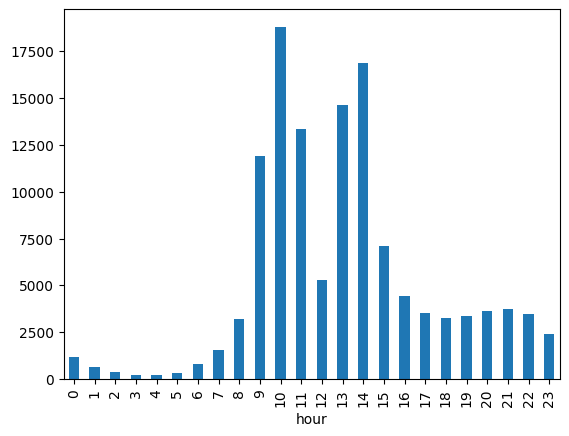

In [80]:
# 绘制hour_counts的柱状图

hour_counts.plot(kind = "bar")

对于一些简单的数据，可以直接使用plot()进行画图

<font color=blue face=雅黑>思考：按hour分布为什么这个样子呢？</font>

## 8.3 Groupby

这里我们引入groupby函数来实现相似的功能。之前我们尝试使用max或mean函数对序列进行汇总，求最大值或均值，这些都是求全局汇总运算。然而，要更深入地研究数据，简单的聚合汇总通常是不够的。groupby操作允许您快速而有效地计算数据子集上的聚合。groupby聚合运算参见下图，参考资料《Python Data Science Handbook》，作者Jake VanderPlas。

<img src="../img/groupby.png" align='left' height="300" width="400"/>

In [81]:
# Sort group keys. Groupby preserves the order of rows within each group.

comments_group_by_hour = comments.groupby(["hour"],sort=True) # 生成一个groupby的对象
comments_group_by_hour

In [82]:
# The GroupBy object is a very flexible abstraction. 
# you can simply treat it as if it’s a collection of DataFrames
for (hour,group) in comments_group_by_hour:
    print(hour)
    print(group.shape)
    # break

(0,)
(1168, 4)
(1,)
(628, 4)
(2,)
(352, 4)
(3,)
(237, 4)
(4,)
(235, 4)
(5,)
(341, 4)
(6,)
(809, 4)
(7,)
(1573, 4)
(8,)
(3213, 4)
(9,)
(11910, 4)
(10,)
(18797, 4)
(11,)
(13354, 4)
(12,)
(5283, 4)
(13,)
(14612, 4)
(14,)
(16858, 4)
(15,)
(7111, 4)
(16,)
(4442, 4)
(17,)
(3547, 4)
(18,)
(3246, 4)
(19,)
(3351, 4)
(20,)
(3648, 4)
(21,)
(3755, 4)
(22,)
(3449, 4)
(23,)
(2401, 4)


In [83]:
# 对于分组的某个序列进行汇总预算，这里仅仅是计数（不等于0的）
import numpy as np
grouped_hour = comments_group_by_hour.aggregate(np.count_nonzero)

<Axes: xlabel='hour'>

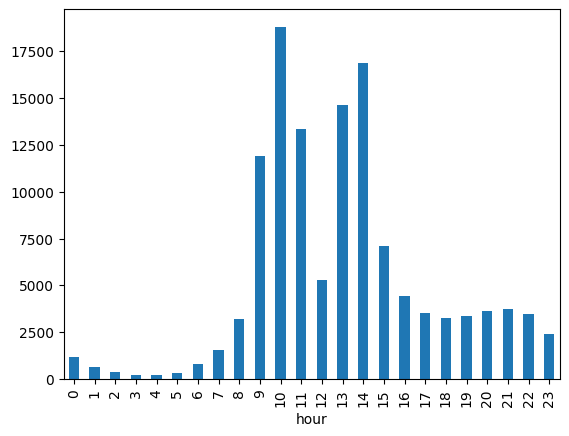

In [84]:
grouped_hour
grouped_hour.comment.plot(kind="bar") # comment，month，dayofweek

## 8.4 Group by dayofweek and hour

In [85]:
# 根据["dayofweek","hour"]进行分组，不同的时间点是否有差异呢？

comments_group_by_dayofweek_hour = comments.groupby(["dayofweek","hour"],sort=True)

In [86]:
# 在分组内统计评论个数

grouped_dayofweek_hour = comments_group_by_dayofweek_hour.aggregate(np.count_nonzero)
grouped_dayofweek_hour
#grouped_dayofweek_hour[1:49]

comment  month
dayofweek hour                
1         0         134    134
          1          75     75
          2          36     36
          3          23     23
          4          21     21
...                 ...    ...
7         19        286    286
          20        305    305
          21        359    359
          22        284    284
          23        250    250

[168 rows x 2 columns]

In [87]:
# 查看grouped_dayofweek_hour的index，这是MultiIndex

# 使用unstack函数将最内层的行索引还原成了列索引

grouped_dayofweek_hour.comment.unstack()

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dayofweek,,,,,,,,,,,,,,,,,,,,,
1,134,75,36,23,21,29,108,215,435,2389,...,3007,277,301,319,311,323,367,412,424,292
2,176,94,51,33,39,75,138,273,550,2035,...,3219,1280,807,607,542,573,683,631,537,390
3,159,97,47,42,54,59,132,275,548,2161,...,3239,1203,709,547,473,506,562,589,554,425
4,217,117,66,42,40,52,154,249,592,2266,...,3405,1355,802,621,609,597,617,646,622,359
5,182,91,79,45,40,69,131,293,623,2363,...,3369,1415,828,657,591,591,638,639,592,404
6,161,79,43,33,30,31,79,144,229,388,...,337,1247,691,550,461,475,476,479,436,281
7,139,75,30,19,11,26,67,124,236,308,...,282,334,304,246,259,286,305,359,284,250


In [88]:
# 使用unstack函数将最内层的行索引还原成了列索引

unstack_grouped_dayofweek_hour = grouped_dayofweek_hour.comment.unstack()
unstack_grouped_dayofweek_hour

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dayofweek,,,,,,,,,,,,,,,,,,,,,
1,134,75,36,23,21,29,108,215,435,2389,...,3007,277,301,319,311,323,367,412,424,292
2,176,94,51,33,39,75,138,273,550,2035,...,3219,1280,807,607,542,573,683,631,537,390
3,159,97,47,42,54,59,132,275,548,2161,...,3239,1203,709,547,473,506,562,589,554,425
4,217,117,66,42,40,52,154,249,592,2266,...,3405,1355,802,621,609,597,617,646,622,359
5,182,91,79,45,40,69,131,293,623,2363,...,3369,1415,828,657,591,591,638,639,592,404
6,161,79,43,33,30,31,79,144,229,388,...,337,1247,691,550,461,475,476,479,436,281
7,139,75,30,19,11,26,67,124,236,308,...,282,334,304,246,259,286,305,359,284,250


plt.subplots: The Whole Grid in One Go，参考Aurélien Géron：Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow. 2019,O’Reilly Media, Inc.

**plt.subplots()是一个函数，返回一个包含 figure 和 axes 对象的元组。因此，使用 fig,ax =**

In [89]:
import matplotlib.pyplot as plt

# IPython提供的一个有趣的后端是inline。有了这个后端，绘图命令的输出在前端显示，

# 就像Jupyter notebook 一样，直接显示在生成它的代码单元（cell）的下面。

%matplotlib inline

In [90]:
import numpy as np

In [91]:
x = np.linspace(0, 10, 100)
# len(x)
x

array([ 0.        ,  0.1010101 ,  0.2020202 ,  0.3030303 ,  0.4040404 ,
        0.50505051,  0.60606061,  0.70707071,  0.80808081,  0.90909091,
        1.01010101,  1.11111111,  1.21212121,  1.31313131,  1.41414141,
        1.51515152,  1.61616162,  1.71717172,  1.81818182,  1.91919192,
        2.02020202,  2.12121212,  2.22222222,  2.32323232,  2.42424242,
        2.52525253,  2.62626263,  2.72727273,  2.82828283,  2.92929293,
        3.03030303,  3.13131313,  3.23232323,  3.33333333,  3.43434343,
        3.53535354,  3.63636364,  3.73737374,  3.83838384,  3.93939394,
        4.04040404,  4.14141414,  4.24242424,  4.34343434,  4.44444444,
        4.54545455,  4.64646465,  4.74747475,  4.84848485,  4.94949495,
        5.05050505,  5.15151515,  5.25252525,  5.35353535,  5.45454545,
        5.55555556,  5.65656566,  5.75757576,  5.85858586,  5.95959596,
        6.06060606,  6.16161616,  6.26262626,  6.36363636,  6.46464646,
        6.56565657,  6.66666667,  6.76767677,  6.86868687,  6.96

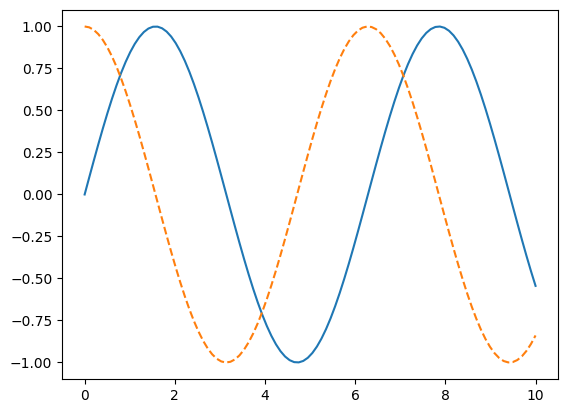

In [92]:
fig = plt.figure() # 画图开始

plt.plot(x, np.sin(x), '-')
plt.plot(x, np.cos(x), '--') # s .-
plt.savefig("my_figure.png")

fig = plt.figure(figsize=(16,16),dpi=300) # 初始化一张画布，可是设置figsize和dpi。

plt，plot() # 直接在一张大的画布中画图，相当于获取当前活跃的axes，然后在上面做图。

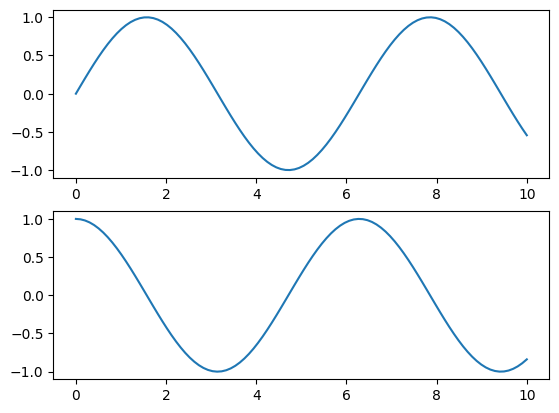

In [93]:
plt.figure()
# create the first of two panels and set current axis
plt.subplot(2, 1, 1) # (rows, columns, panel number)
plt.plot(x, np.sin(x))
# create the second panel and set current axis
plt.subplot(2, 1, 2)
plt.plot(x, np.cos(x))

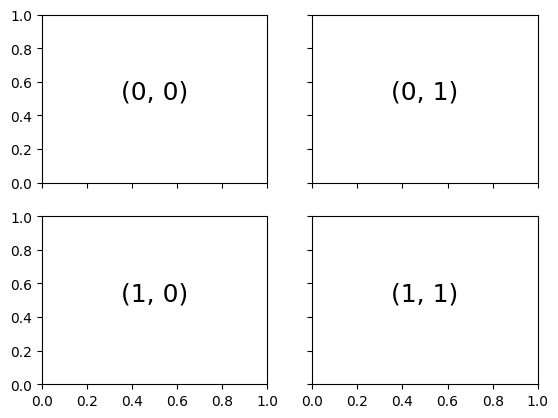

In [94]:
fig, ax = plt.subplots(2,2,sharex=True,sharey = True) # 2行 2列 
for i in range(2):
    for j in range(2):
        ax[i, j].text(0.5, 0.5, str((i, j)), # 每个区域加一个文本
        fontsize=18, ha='center')

In [95]:
ax

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

In [96]:
grouped_dayofweek_hour_unstack = grouped_dayofweek_hour.comment.unstack()
grouped_dayofweek_hour_unstack # 如何取出数据画图呢？

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dayofweek,,,,,,,,,,,,,,,,,,,,,
1,134,75,36,23,21,29,108,215,435,2389,...,3007,277,301,319,311,323,367,412,424,292
2,176,94,51,33,39,75,138,273,550,2035,...,3219,1280,807,607,542,573,683,631,537,390
3,159,97,47,42,54,59,132,275,548,2161,...,3239,1203,709,547,473,506,562,589,554,425
4,217,117,66,42,40,52,154,249,592,2266,...,3405,1355,802,621,609,597,617,646,622,359
5,182,91,79,45,40,69,131,293,623,2363,...,3369,1415,828,657,591,591,638,639,592,404
6,161,79,43,33,30,31,79,144,229,388,...,337,1247,691,550,461,475,476,479,436,281
7,139,75,30,19,11,26,67,124,236,308,...,282,334,304,246,259,286,305,359,284,250


* .loc is primarily label based indexing # 标签作为索引（名称）
* .iloc is primarily integer position based indexing # 用整数位置作为索引
[iloc](https://pandas.pydata.org/pandas-docs/version/0.22/indexing.html#indexing-integer)

In [97]:
grouped_dayofweek_hour_unstack.loc[[1],:] # 使用第一行的名称索引

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dayofweek,,,,,,,,,,,,,,,,,,,,,
1,134,75,36,23,21,29,108,215,435,2389,...,3007,277,301,319,311,323,367,412,424,292


In [98]:
grouped_dayofweek_hour_unstack.iloc[[0],:] #使用第一行的位置索引  不加中括号会变成序列

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dayofweek,,,,,,,,,,,,,,,,,,,,,
1,134,75,36,23,21,29,108,215,435,2389,...,3007,277,301,319,311,323,367,412,424,292


<Axes: xlabel='hour'>

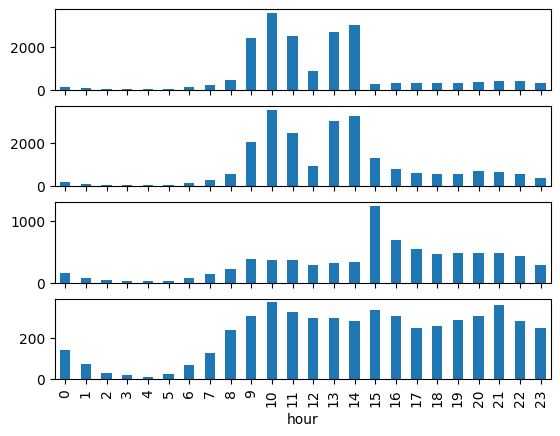

In [99]:
fig, ax = plt.subplots(4,1,sharex=True)
grouped_dayofweek_hour_unstack.iloc[0,:].plot(kind='bar',ax=ax[0])
grouped_dayofweek_hour_unstack.iloc[1,:].plot(kind='bar',ax=ax[1])
grouped_dayofweek_hour_unstack.iloc[5,:].plot(kind='bar',ax=ax[2])
grouped_dayofweek_hour_unstack.iloc[6,:].plot(kind='bar',ax=ax[3])

<font color=blue face=雅黑>思考：大家分析上图能够发现什么规律呢？</font>

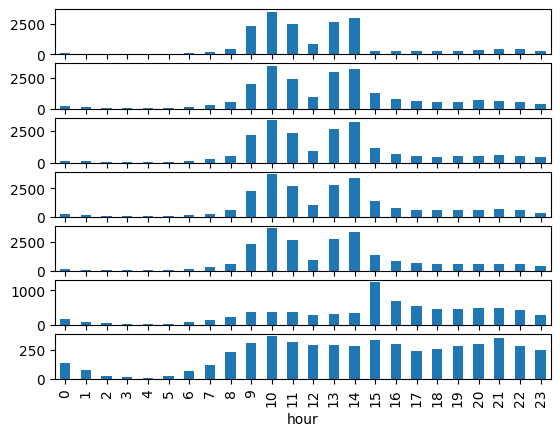

In [100]:
# 通过循环我们画出一周内每天每个时间段的评论分布情况
fig, ax = plt.subplots(7,1,sharex=True)
for i in range(7):
    grouped_dayofweek_hour.comment.unstack().iloc[i,:].plot(kind='bar',ax=ax[i])

**Thanks a lot for your attention!**